# <font color= 'aqua'><b><u>Assignment 4</u></b></font>

## Objective:
     
*   Implement and compare Linear, Ridge, and Lasso Regression models.
*   To train linear models on a curated dataset.
*   To evaluate performances of the models using MAE, MSE, and R² score.
*   To observe impact of regulariza on (L1 vs. L2) on model performance and coefficients.


# <font color= 'aqua'><b>Imports:</b></font>

In [79]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# <font color= 'aqua'><b>Dataset:</b></font>

In [80]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
automobile = fetch_ucirepo(id=10)

# data (as pandas dataframes)
X = automobile.data.features
y = automobile.data.targets


# <font color= 'aqua'><b>Converting To Data Frame:</b></font>

In [81]:
automobile_df = pd.DataFrame(X)
automobile_df['target'] = y
print(automobile_df.head())

     price  highway-mpg  city-mpg  peak-rpm  horsepower  compression-ratio  \
0  13495.0           27        21    5000.0       111.0                9.0   
1  16500.0           27        21    5000.0       111.0                9.0   
2  16500.0           26        19    5000.0       154.0                9.0   
3  13950.0           30        24    5500.0       102.0               10.0   
4  17450.0           22        18    5500.0       115.0                8.0   

   stroke  bore fuel-system  engine-size  ...  wheel-base engine-location  \
0    2.68  3.47        mpfi          130  ...        88.6           front   
1    2.68  3.47        mpfi          130  ...        88.6           front   
2    3.47  2.68        mpfi          152  ...        94.5           front   
3    3.40  3.19        mpfi          109  ...        99.8           front   
4    3.40  3.19        mpfi          136  ...        99.4           front   

   drive-wheels   body-style  num-of-doors  aspiration  fuel-type  \

# <font color= 'aqua'><b>Data Analysis:</b></font>

In [82]:
automobile_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   price              201 non-null    float64
 1   highway-mpg        205 non-null    int64  
 2   city-mpg           205 non-null    int64  
 3   peak-rpm           203 non-null    float64
 4   horsepower         203 non-null    float64
 5   compression-ratio  205 non-null    float64
 6   stroke             201 non-null    float64
 7   bore               201 non-null    float64
 8   fuel-system        205 non-null    object 
 9   engine-size        205 non-null    int64  
 10  num-of-cylinders   205 non-null    int64  
 11  engine-type        205 non-null    object 
 12  curb-weight        205 non-null    int64  
 13  height             205 non-null    float64
 14  width              205 non-null    float64
 15  length             205 non-null    float64
 16  wheel-base         205 non

In [83]:
print(automobile_df.describe())

              price  highway-mpg    city-mpg     peak-rpm  horsepower  \
count    201.000000   205.000000  205.000000   203.000000  203.000000   
mean   13207.129353    30.751220   25.219512  5125.369458  104.256158   
std     7947.066342     6.886443    6.542142   479.334560   39.714369   
min     5118.000000    16.000000   13.000000  4150.000000   48.000000   
25%     7775.000000    25.000000   19.000000  4800.000000   70.000000   
50%    10295.000000    30.000000   24.000000  5200.000000   95.000000   
75%    16500.000000    34.000000   30.000000  5500.000000  116.000000   
max    45400.000000    54.000000   49.000000  6600.000000  288.000000   

       compression-ratio      stroke        bore  engine-size  \
count         205.000000  201.000000  201.000000   205.000000   
mean           10.142537    3.255423    3.329751   126.907317   
std             3.972040    0.316717    0.273539    41.642693   
min             7.000000    2.070000    2.540000    61.000000   
25%             8

In [84]:
automobile_df.skew(numeric_only=True)

,0
price,1.809675
highway-mpg,0.539997
city-mpg,0.663704
peak-rpm,0.073237
horsepower,1.391029
compression-ratio,2.610862
stroke,-0.683122
bore,0.020016
engine-size,1.947655
num-of-cylinders,2.817459


In [85]:
automobile_df.isna().sum()

,0
price,4
highway-mpg,0
city-mpg,0
peak-rpm,2
horsepower,2
compression-ratio,0
stroke,4
bore,4
fuel-system,0
engine-size,0


# <font color= 'aqua'><b>Error handling:</b></font>

In [86]:
automobile_df['price'] = automobile_df['price'].fillna(automobile_df['price'].median())
automobile_df['peak-rpm'] = automobile_df['peak-rpm'].fillna(automobile_df['peak-rpm'].mean())
automobile_df['horsepower'] = automobile_df['horsepower'].fillna(automobile_df['horsepower'].median())
automobile_df['stroke'] = automobile_df['stroke'].fillna(automobile_df['stroke'].median())
automobile_df['bore'] = automobile_df['bore'].fillna(automobile_df['bore'].mean())
automobile_df['num-of-doors'] = automobile_df['num-of-doors'].fillna(automobile_df['num-of-doors'].median())
automobile_df['normalized-losses'] = automobile_df['normalized-losses'].fillna(automobile_df['normalized-losses'].median())
automobile_df.isna().sum()

,0
price,0
highway-mpg,0
city-mpg,0
peak-rpm,0
horsepower,0
compression-ratio,0
stroke,0
bore,0
fuel-system,0
engine-size,0


# <font color= 'aqua'><b>Separating Data:</b></font>

In [87]:
input = automobile_df.drop(columns= ['price', 'target', 'make'])
target = automobile_df['price']

In [88]:
X_train, X_test, y_train, y_test = train_test_split(input, target, test_size=0.2, random_state=42)

# <font color= 'aqua'><b>Processing Data:</b></font>

In [89]:
cat_cols = input.select_dtypes(include=['object']).columns
num_cols = input.select_dtypes(exclude=['object']).columns

preprocess = ColumnTransformer(
    transformers= [
        ("cat", OneHotEncoder(drop='first', sparse_output= False), cat_cols),
        ('num', MinMaxScaler(), num_cols)
    ],
    remainder='passthrough',
    force_int_remainder_cols=False
)

# <font color= 'aqua'><b>Defining Models:</b></font>

In [90]:
models = {
    "Linear Regrassion": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5)
}

# <font color= 'aqua'><b>Storing Results:</b></font>

In [91]:
results = []

for name, model in models.items():

    pipeline = Pipeline([
        ('processing', preprocess),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mse)

    results.append({
        "Model": name,
        "MSE": mse,
        "MAE": mae,
        "R2 Score": r2,
        "RMSE": rmse
    })

# <font color= 'aqua'><b>Display Result:</b></font>

In [92]:
results_df = pd.DataFrame(results)
print(results_df)

               Model           MSE          MAE  R2 Score         RMSE
0  Linear Regrassion  1.548854e+07  2492.792594  0.802551  3935.547658
1      Decision Tree  7.006713e+06  1879.731707  0.910678  2647.019728
2      Random Forest  5.524977e+06  1529.163862  0.929567  2350.527030
3  Gradient Boosting  7.001286e+06  1813.468482  0.910747  2645.994424
4      KNN Regressor  2.320841e+07  2970.292683  0.704138  4817.510466


# <font color= 'aqua'><b>Visual Representation:</b></font>

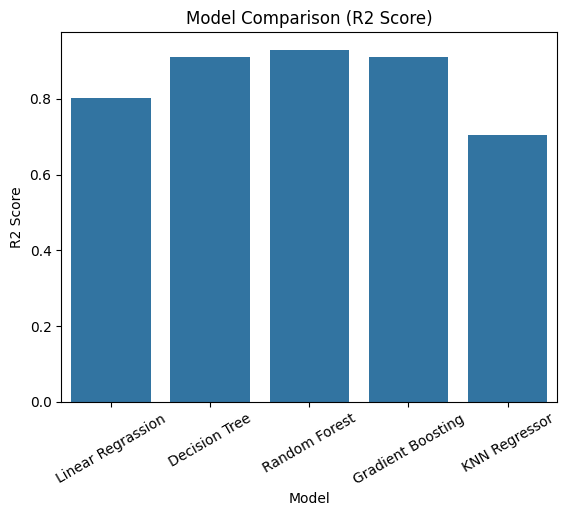

In [93]:
sns.barplot(data=results_df, x='Model', y='R2 Score')
plt.title("Model Comparison (R2 Score)")
plt.xticks(rotation=30)
plt.show()

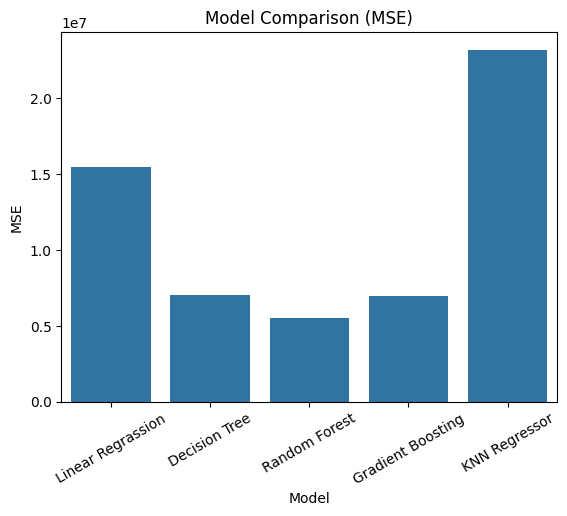

In [94]:
sns.barplot(data=results_df, x='Model', y='MSE')
plt.title("Model Comparison (MSE)")
plt.xticks(rotation=30)
plt.show()

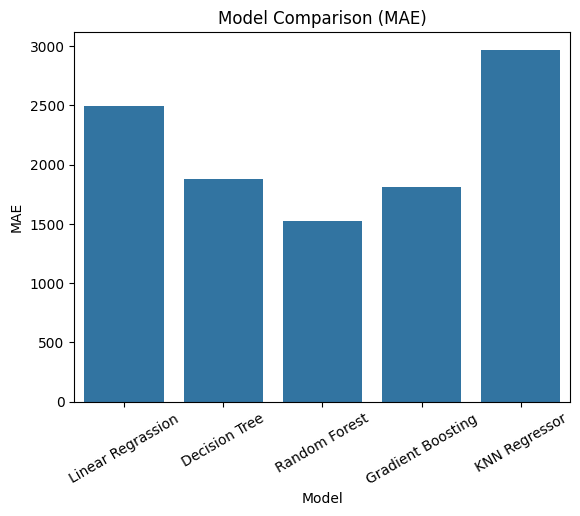

In [95]:
sns.barplot(data=results_df, x='Model', y='MAE')
plt.title("Model Comparison (MAE)")
plt.xticks(rotation=30)
plt.show()